输出的为每一类的置信值$\bf y$

$$\hat{y}=\argmax _i{o_i}$$

对于特殊,要拉开距离
$$o_y-o_i\ge \Delta (y,i)$$

将结果转换为概率
$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o})\quad \text{其中}\quad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$

信息熵
$$H[P] = \sum_j - P(j) \log P(j)$$
交叉熵
$$l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j$$
$\bf y$是一个长度$q$为的独热编码向量,其中只有$y_y=1$

所以$l(\mathbf{y}, \hat{\mathbf{y}}) = -\log \hat{y}_y$

$$\begin{split}\begin{aligned}
l(\mathbf{y}, \hat{\mathbf{y}}) &=  - \sum_{j=1}^q y_j \log \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} \\
&= \sum_{j=1}^q y_j \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j\\
&= \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j.
\end{aligned}\end{split}\\
\partial_{o_j} l(\mathbf{y}, \hat{\mathbf{y}}) = \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} - y_j = \mathrm{softmax}(\mathbf{o})_j - y_j.$$

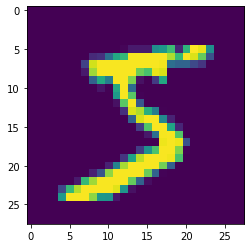

In [15]:
import mine_torch
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils import data
import numpy as np

# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0到1之间
trans = torchvision.transforms.ToTensor()
mnist_train = torchvision.datasets.MNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
    root="./data", train=False, transform=trans, download=True)
plt.imshow(mnist_train[0][0][0])
plt.show()

In [16]:
mnist_train[0][0]#第0维是某个example
#第一维为一个元组(data,lable)
#图像为(1,28,28),1代表单通道

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

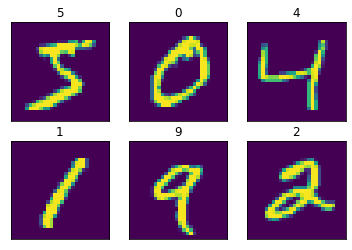

In [17]:
fig,axes=plt.subplots(2,3)
axes=axes.flatten()#一维
for i in range(6):
    ax=axes[i]
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.imshow(mnist_train[i][0][0])
    ax.set_title(mnist_train[i][1])
plt.show()

In [18]:
batch_size=256
num_input=28*28
num_output=10

train_iter=data.DataLoader(mnist_train,256,True)
test_iter=data.DataLoader(mnist_test,256,True)
W=torch.normal(0,0.01,size=(num_input,num_output),requires_grad=True)
b=torch.zeros(num_output,requires_grad=True)

def softmax(X):
    X_exp=torch.exp(X)
    partition=X_exp.sum(dim=1,keepdim=True)
    return X_exp/partition#广播机制 自动补全

def net(X):#数据(256*784) W(784,10)
    return softmax(torch.matmul(X.reshape((-1,num_input)),W)+b)


In [19]:
y = torch.tensor([0, 2])#直接写索引就行
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]#[y_hat[0,0],y_hat[1,2]]

tensor([0.1000, 0.5000])

In [20]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [21]:
def my_reshape(X):
    temp=[i[0].reshape(num_input) for i in X]
    train_temp=torch.zeros(len(X),num_input)#形状必须完全一致

    for i in range(len(X)):
        train_temp[i]=temp[i]
    return train_temp

mnist_train_features=my_reshape(mnist_train)
mnist_test_features=my_reshape(mnist_test)
mnist_train_features.shape

torch.Size([60000, 784])

In [22]:

def one_hot_lables(X):#独热化标签
    lable_temp=torch.zeros(len(X),num_output)
    index=[i[1] for i in X]
    for i in range(len(X)):
        lable_temp[i][index[i]]=1
    return lable_temp
one_hot_lables(mnist_train).shape


torch.Size([60000, 10])

In [23]:
net(mnist_train_features)

tensor([[0.1096, 0.1028, 0.1124,  ..., 0.0960, 0.0967, 0.0852],
        [0.1187, 0.1103, 0.0961,  ..., 0.0887, 0.1020, 0.0887],
        [0.0919, 0.1007, 0.1067,  ..., 0.1081, 0.0992, 0.0936],
        ...,
        [0.1083, 0.0996, 0.1012,  ..., 0.0999, 0.0977, 0.0880],
        [0.0896, 0.1087, 0.0898,  ..., 0.0880, 0.1178, 0.1039],
        [0.1055, 0.0963, 0.0973,  ..., 0.0992, 0.1161, 0.0970]],
       grad_fn=<DivBackward0>)

In [24]:
def cal_acc(X,y):
    tot=0
    for i in range(X.shape[0]):
        if(net(X[i]).argmax()==y[i]):
            tot+=1
    return tot/X.shape[0]
#计算准确率

In [25]:
y_train=torch.tensor([i[1] for i in mnist_train])
y_test=torch.tensor([i[1] for i in mnist_test])

cal_acc(mnist_train_features,y_train)

0.10696666666666667

In [26]:

loss=cross_entropy(net(mnist_train_features),y_train).mean()

epochs=100
lr=0.08
acc=[]#准确率
length=len(mnist_train)
for epoch in range(epochs):
    loss=cross_entropy(net(mnist_train_features),y_train).mean()
    loss.backward()
    
    with torch.no_grad():#更新时不用计算梯度
        #非常重要
        W-=(W.grad)*lr
        W.grad.zero_()  
        b-=(b.grad)*lr
        b.grad.zero_()
    if(epoch%10==0):
        acc.append(cal_acc(mnist_train_features,y_train))  
    print(f'epoch {epoch + 1}, loss {loss.item():f}')



epoch 1, loss 2.301220
epoch 2, loss 2.216686
epoch 3, loss 2.138131
epoch 4, loss 2.064515
epoch 5, loss 1.995299
epoch 6, loss 1.930148
epoch 7, loss 1.868809
epoch 8, loss 1.811066
epoch 9, loss 1.756713
epoch 10, loss 1.705557
epoch 11, loss 1.657406
epoch 12, loss 1.612077
epoch 13, loss 1.569392
epoch 14, loss 1.529182
epoch 15, loss 1.491282
epoch 16, loss 1.455540
epoch 17, loss 1.421809
epoch 18, loss 1.389952
epoch 19, loss 1.359842
epoch 20, loss 1.331358
epoch 21, loss 1.304389
epoch 22, loss 1.278831
epoch 23, loss 1.254588
epoch 24, loss 1.231572
epoch 25, loss 1.209698
epoch 26, loss 1.188892
epoch 27, loss 1.169083
epoch 28, loss 1.150204
epoch 29, loss 1.132197
epoch 30, loss 1.115006
epoch 31, loss 1.098578
epoch 32, loss 1.082867
epoch 33, loss 1.067828
epoch 34, loss 1.053421
epoch 35, loss 1.039607
epoch 36, loss 1.026353
epoch 37, loss 1.013624
epoch 38, loss 1.001392
epoch 39, loss 0.989628
epoch 40, loss 0.978306
epoch 41, loss 0.967401
epoch 42, loss 0.956892
e

In [27]:
cal_acc(mnist_train_features,y_train)

0.856

In [28]:
for i in range(50):
    print(f'predict:{net(mnist_train_features[i]).argmax()} real:{y_train[i]}')

predict:5 real:5
predict:0 real:0
predict:4 real:4
predict:1 real:1
predict:9 real:9
predict:2 real:2
predict:1 real:1
predict:3 real:3
predict:1 real:1
predict:4 real:4
predict:3 real:3
predict:2 real:5
predict:3 real:3
predict:6 real:6
predict:1 real:1
predict:7 real:7
predict:2 real:2
predict:8 real:8
predict:6 real:6
predict:7 real:9
predict:4 real:4
predict:0 real:0
predict:9 real:9
predict:1 real:1
predict:6 real:1
predict:2 real:2
predict:4 real:4
predict:3 real:3
predict:7 real:2
predict:7 real:7
predict:3 real:3
predict:8 real:8
predict:6 real:6
predict:7 real:9
predict:0 real:0
predict:5 real:5
predict:6 real:6
predict:0 real:0
predict:7 real:7
predict:6 real:6
predict:1 real:1
predict:8 real:8
predict:7 real:7
predict:9 real:9
predict:3 real:3
predict:9 real:9
predict:8 real:8
predict:5 real:5
predict:5 real:9
predict:3 real:3


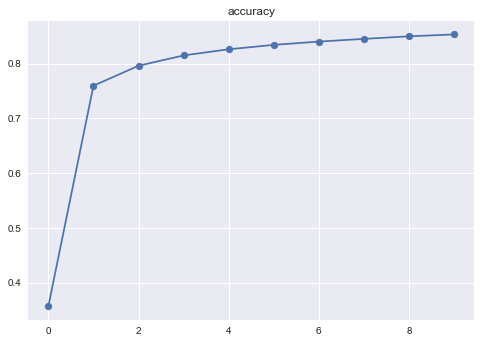

In [29]:
plt.style.use('seaborn')
fig,ax=plt.subplots()
ax.set_title("accuracy")
ax.scatter(range(int(epochs/10)),acc)
ax.plot(range(int(epochs/10)),acc)

In [30]:
cal_acc(mnist_test_features,y_test)

0.864

In [50]:
#实现批量梯度下降
#ratio指acc的百分比
ratio=10
W=torch.normal(0,0.01,size=(num_input,num_output),requires_grad=True)
b=torch.zeros(num_output,requires_grad=True)

for epoch in range(epochs):
    out=mine_torch.select(mnist_train_features,y_train,256)
    loss=cross_entropy(net(out[0]),out[1]).mean()
    loss.backward()

    with torch.no_grad():#更新时不用计算梯度
        #非常重要
        W-=(W.grad)*lr
        W.grad.zero_()  
        b-=(b.grad)*lr
        b.grad.zero_()
    if(epoch%ratio==0):
        print(f'epoch {epoch }, accuracy {cal_acc(mnist_train_features,y_train):f}')


epoch 0, accuracy 0.347933
epoch 10, accuracy 0.743967
epoch 20, accuracy 0.776500
epoch 30, accuracy 0.803900
epoch 40, accuracy 0.823500
epoch 50, accuracy 0.826383
epoch 60, accuracy 0.833617
epoch 70, accuracy 0.840800
epoch 80, accuracy 0.846850
epoch 90, accuracy 0.849983


In [37]:
cal_acc(mnist_train_features,y_train)

0.8487833333333333